In [ ]:
import pandas as pd
otc_sales = pd.read_csv(r'D:\BOOTCAMP 4 Months\OTC Sales\pharmacy_otc_sales_data_extended.csv')
branch_details = pd.read_csv(r'D:\BOOTCAMP 4 Months\OTC Sales\branch_demographics_chicago.csv')

In [3]:
otc_sales_branch = otc_sales.merge(branch_details, on = 'Branch ID', how = 'inner')

In [ ]:
sales_by_branch = otc_sales_branch.groupby('Branch ID').agg({'Amount ($)': 'sum', 'units_sold': 'sum','Population': 'first'}).reset_index().sort_values(by = 'Amount ($)', ascending = False)
print(sales_by_branch)

In [ ]:
otc_sales_branch.drop(columns=['Date','Population','Total Healthcare Centers','Median Income ($)']).describe(include = 'all').drop(index = ['count','unique','freq'] )

In [ ]:
otc_sales_branch.drop(columns=['Date','Population','Total Healthcare Centers','Median Income ($)']).describe(include = 'all').drop(index = ['count','unique','freq'] )

In [ ]:
otc_sales_branch.groupby('category').sum()

In [10]:
otc_sales_branch.columns.tolist()

['Date',
 'Medication',
 'sales person',
 'Category',
 'units_sold',
 'Amount ($)',
 'Branch ID',
 'Payment Method',
 'Branch Name',
 'Chicago District/Neighborhood',
 'Population',
 'Total Healthcare Centers',
 'Median Income ($)']

In [ ]:
sales_cor = otc_sales_branch[['units_sold','Amount ($)','Population','Total Healthcare Centers', 'Median Income ($)']].corr()
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(sales_cor, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap of Sales Data')
plt.show()

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Date'>

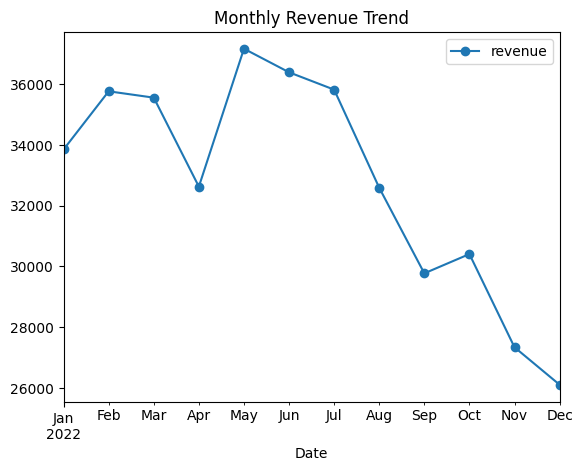

In [22]:
otc_sales_branch['Date'] = pd.to_datetime(otc_sales_branch['Date'])
monthly = otc_sales_branch.set_index('Date').resample('ME').agg(
    revenue=('Amount ($)', 'sum'),
    boxes=('units_sold', 'sum')
)
monthly.plot(y='revenue', marker='o', title='Monthly Revenue Trend')